In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import pickle

from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer

import sys
sys.path.append('../..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (8, 8),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'grid.alpha': 0.3,
    'font.family': 'arial',
    'legend.frameon': False,
    'mathtext.fontset': 'cm',
})

# Output directory for plots
PLOT_DIR = Path('plots/1d_regression/')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {PLOT_DIR.absolute()}")

Using device: mps
Plots will be saved to: /Users/sambt/iaifi/sv3/claude_experiments/microbatch_experiments/plots/1d_regression


In [2]:
LOADER_SEED = 51159
MODEL_SEED = 4372892
DATA_SEED = 54631
batch_size = 32
microbatch_sizes = [1,2,4,8,16,32]
K = 16
lr_svd = 0.1
n_epoch = 20
lr_standard = 1e-3
rtol = 1e-3
drop_last = True
mlp_kwargs = {
    "input_dim": 1,
    "hidden_dims": [16,16,16],
    "output_dim": 1
}
standard_optimizers = ['Adam','SGD','RMSprop']

In [3]:
from torchvision import datasets, transforms
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset(seed=DATA_SEED)
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [4]:
set_seed(MODEL_SEED)
mlp_base = MLP(**mlp_kwargs)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### load in results from scan

In [7]:
# Load all experiment results and combine into single DataFrame
RESULTS_DIR = Path('../../experiment_results/toy_1d_scan/')

all_dfs = []
file_pattern = '*.pkl'

for filepath in sorted(RESULTS_DIR.glob(file_pattern)):
    with open(filepath, 'rb') as f:
        df_temp = pickle.load(f)
    all_dfs.append(df_temp)
    print(f"Loaded {filepath.name}: {len(df_temp)} rows")

df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal: {len(df)} experiment runs")
print(f"\nColumns: {df.columns.tolist()}")

df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

df_svd = df_svd[(df_svd['k'] == K) & (df_svd['lr'] == lr_svd) & (df_svd['batch_size'] == batch_size)]
df_baseline = df_baseline[df_baseline['batch_size'] == batch_size]

Loaded toy_1d_scan_results_bs128_df.pkl: 24 rows
Loaded toy_1d_scan_results_bs32_df.pkl: 24 rows
Loaded toy_1d_scan_results_bs64_df.pkl: 24 rows

Total: 72 experiment runs

Columns: ['batch_size', 'k_fraction', 'k', 'lr', 'losses', 'svd_info', 'optimizer']


### Baseline trainings

In [24]:
device = 'cpu'
new_rows = []
for opt_name in standard_optimizers:
    for lr_standard in [0.1,0.01,0.001]:
        if lr_standard in df_baseline[df_baseline['optimizer'] == opt_name].lr.values:
            continue
        print(f"Running standard training with optimizer: {opt_name}, lr: {lr_standard}")
        model_standard = MLP(**mlp_kwargs)
        model_standard.load_state_dict(init_state)
        model_standard = model_standard.to(device)

        opt = getattr(torch.optim, opt_name)
        optimizer = opt(model_standard.parameters(), lr=lr_standard if opt_name != 'SGD' else lr_svd)
        loss_fn = nn.MSELoss()

        train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=drop_last)
        test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

        model_standard, losses = train_loop_standard(model_standard, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)
        losses_standard[opt_name] = losses

        new_row = {
            'optimizer': opt_name,
            'lr': lr_standard,
            'batch_size': batch_size,
            'losses': losses}
        new_rows.append(new_row)
df_baseline = pd.concat([df_baseline, pd.DataFrame(new_rows)], ignore_index=True)

Running standard training with optimizer: Adam, lr: 0.1
Using device cpu


100%|██████████| 20/20 [00:02<00:00,  7.79it/s]


NameError: name 'losses_standard' is not defined

### SVD training with varying microbatch

In [18]:
if device == torch.device('mps'):
    device = 'cpu'  # SVD optimizer not supported on MPS
svd_info = {}
losses_svd = {}
for microbatch_size in [1]:
    print("Running for microbatch size:", microbatch_size)
    model_svd = MLP(**mlp_kwargs)
    model_svd.load_state_dict(init_state)
    model_svd = model_svd.to(device)

    def loss_fn(pred,y):
        loss = (pred - y)**2
        loss = loss.sum(dim=-1)
        return loss

    model_svd = FunctionalModelJac(model_svd, loss_fn, microbatch_size=None, device=device)
    optimizer = SVDOptimizer(model_svd,lr=lr_svd,k=K,rtol=rtol,track_svd_info=True)


    train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=False)
    test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

    model_svd, losses_run, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
    svd_info[microbatch_size] = optimizer.svd_info
    losses_svd[microbatch_size] = losses_run

    torch.compiler.reset()

Running for microbatch size: 1


100%|██████████| 20/20 [00:08<00:00,  2.38it/s]


In [10]:
losses_offby1 = losses_svd[1]['train_batch'].copy()

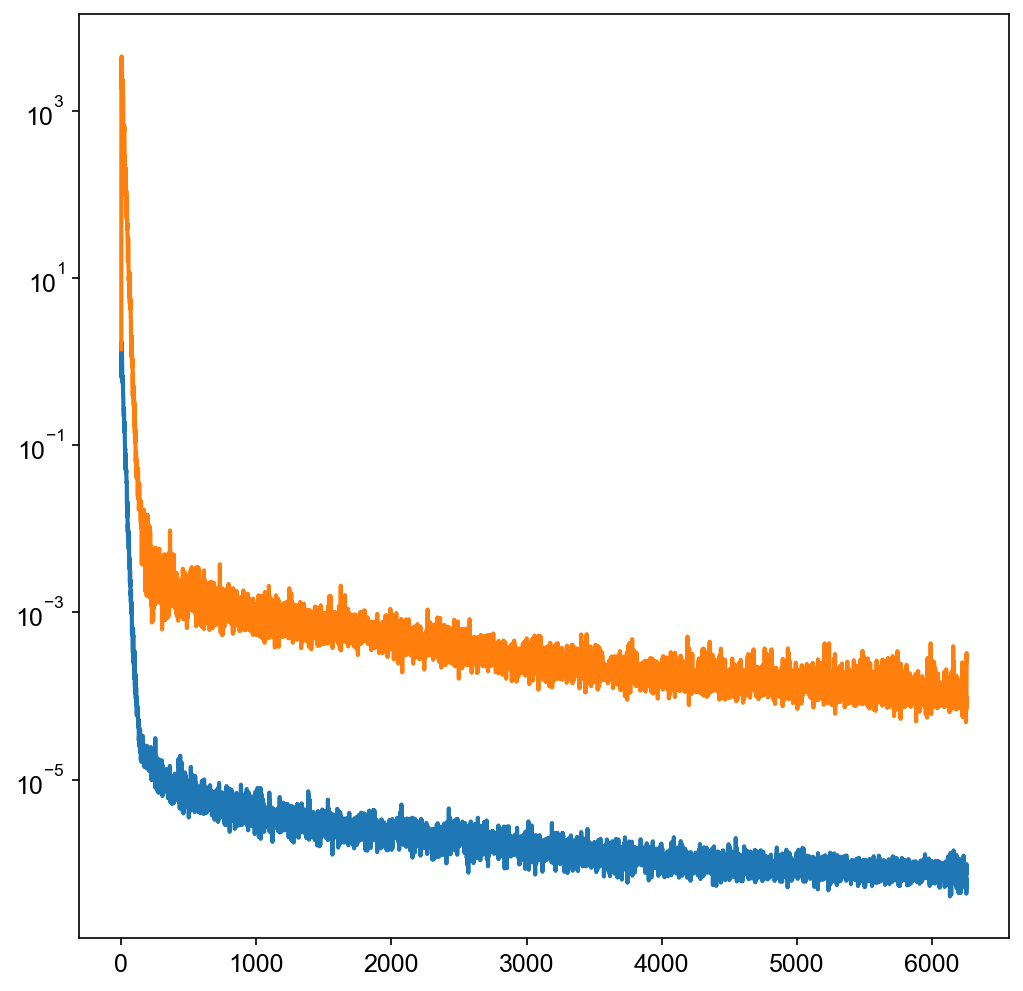

In [19]:
l_ref = df_svd[(df_svd['k'] == K) & (df_svd['lr'] == lr_svd) & (df_svd['batch_size'] == batch_size)].iloc[0].losses
plt.plot(losses_offby1)
plt.plot(losses_svd[1]['train_batch'])
plt.yscale('log')

In [21]:
svd_info[1]['svs']

[array([14.947087  ,  0.3375454 ,  0.09876346,  0.01557641], dtype=float32),
 array([456184.38   ,  16063.956  ,  12807.503  ,   2543.553  ,
          1983.9268 ,   1099.3607 ,    918.7199 ,    516.22864],
       dtype=float32),
 array([312956.1    ,  23460.135  ,   5578.92   ,   2772.4001 ,
          1689.9641 ,   1529.2196 ,    942.48254,    831.13556,
           552.7828 ,    390.63266], dtype=float32),
 array([479897.56   ,  18360.086  ,  10405.87   ,   3239.2322 ,
          3125.4033 ,   2193.9285 ,   1632.972  ,   1022.87476,
           561.8515 ], dtype=float32),
 array([241439.88   ,  20420.867  ,   6846.227  ,   3345.445  ,
          1839.3936 ,   1074.2773 ,    708.12317,    345.4477 ],
       dtype=float32),
 array([400254.25   ,  13519.456  ,   8617.825  ,   2913.4014 ,
          1991.8271 ,   1678.5079 ,   1394.7861 ,    962.54395],
       dtype=float32),
 array([337933.22  ,  15845.246 ,   7947.7754,   2746.977 ,   2123.3901,
          1348.2389,   1013.9756,    425.7868]

In [93]:
l_ref = df_svd[(df_svd['k'] == K) & (df_svd['lr'] == lr_svd) & (df_svd['batch_size'] == batch_size)].iloc[0].svd_info

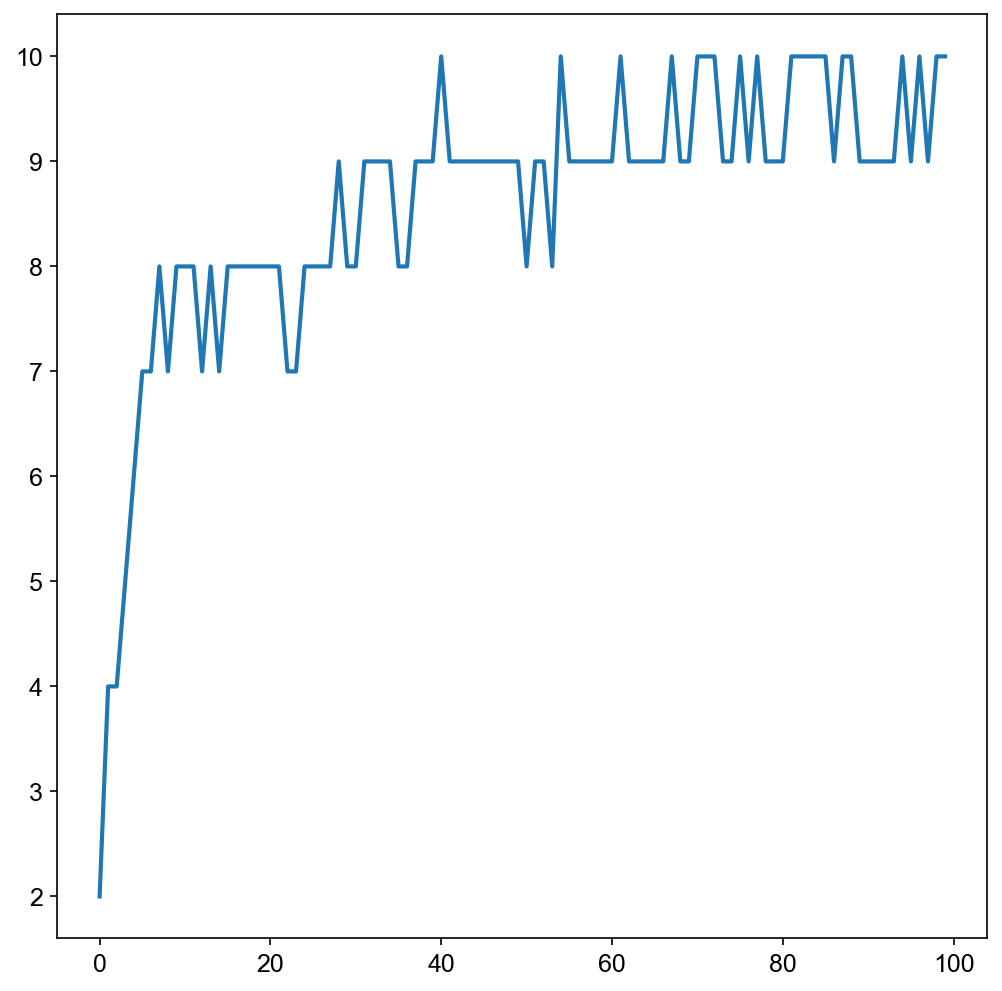

In [94]:
plt.plot(l_ref['num_nonzero_svs'][:100])

### Make plots

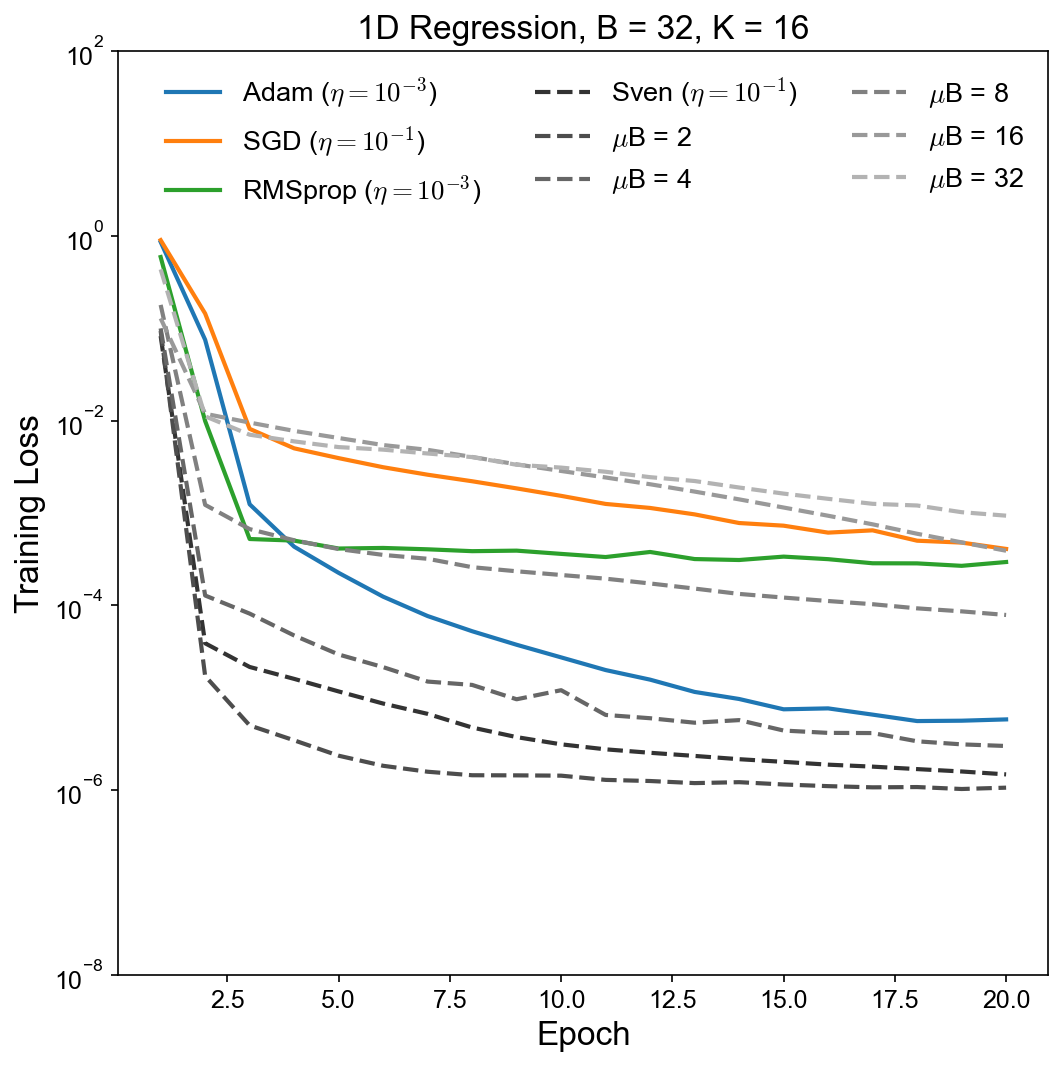

In [51]:
fig, ax = plt.subplots(figsize=(8,8))
for i,opt in enumerate(standard_optimizers):
    ax.plot(np.arange(1,len(losses_standard[opt]['train'])+1), losses_standard[opt]['train'], f'C{i}-', label=f'{opt} ($\\eta=10^{{{int(np.log10(lr_standard)) if opt != "SGD" else int(np.log10(lr_svd))}}}$)')
for i, mb in enumerate(microbatch_sizes):
    gray_intensity = 0.2 + (i / (len(microbatch_sizes) - 1)) * 0.5
    label = rf'$\mu$B = {mb}' if mb > 1 else f'Sven ($\\eta=10^{{{int(np.log10(lr_svd))}}}$)'
    ax.plot(np.arange(1,len(losses_svd[mb]['train'])+1), losses_svd[mb]['train'], 
            color=str(gray_intensity), label=label, linestyle='--')
    
ax.set_title(f"1D Regression, B = {batch_size}, K = {K}")
ax.set_ylabel("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylim(1e-8, 1e2)
plt.yscale('log')
plt.legend(loc='upper right',ncol=3,fontsize=13)
plt.savefig(PLOT_DIR / f"train_loss_1d_regression_microbatch_comparison_bs{batch_size}_K{K}_lr{lr_svd}_rtol{rtol}.png")

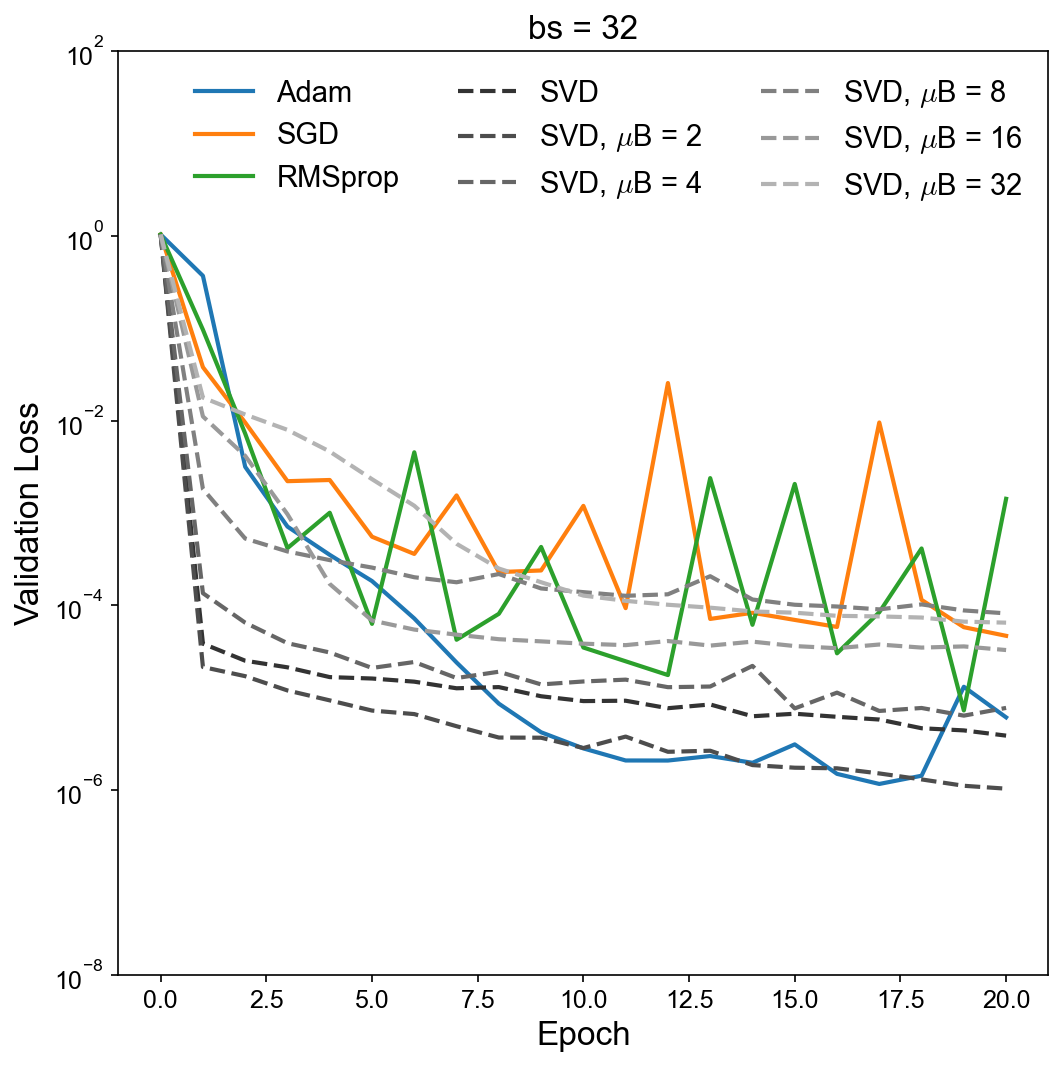

In [45]:
fig, ax = plt.subplots(figsize=(8,8))
for i,opt in enumerate(standard_optimizers):
    ax.plot(np.arange(len(losses_standard[opt]['val'])), losses_standard[opt]['val'], f'C{i}-', label=f'{opt}')
for i, mb in enumerate(microbatch_sizes):
    gray_intensity = 0.2 + (i / (len(microbatch_sizes) - 1)) * 0.5
    label = rf'SVD, $\mu$B = {mb}' if mb > 1 else 'SVD'
    ax.plot(np.arange(len(losses_svd[mb]['val'])), losses_svd[mb]['val'], 
            color=str(gray_intensity), label=label, linestyle='--')
    
ax.set_title(f"bs = {batch_size}")
ax.set_ylabel("Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylim(1e-8, 1e2)
plt.yscale('log')
plt.legend(loc='upper right',ncol=3)
plt.savefig(PLOT_DIR / f"val_loss_1d_regression_microbatch_comparison_bs{batch_size}_K{K}_lr{lr_svd}_rtol{rtol}.png")